# Self-Pruning Neural Network with Gate Visualization
Includes training + sparsity + gate distribution plots.

## Overview

This notebook demonstrates a **self-pruning neural network** that automatically learns to remove unnecessary weights during training. The network uses learnable gates and L1 sparsity regularization to achieve model compression.

### Key Features:
- **Learnable Gates**: Each weight has an associated gate parameter
- **Automatic Pruning**: Gates are pushed toward zero via L1 regularization
- **Sparsity Control**: Adjustable lambda parameter controls pruning strength
- **Visualization**: Gate distribution plots show pruning behavior

### How It Works:
1. Each layer has weights and corresponding gate scores
2. Gates are converted to 0-1 values using sigmoid: `gate = sigmoid(gate_score)`
3. Pruned weights: `weight * gate`
4. Loss includes sparsity penalty: `L1(gate_scores)`
5. Training balances accuracy vs. sparsity

### Expected Results:
- Higher lambda → More sparsity → Lower accuracy
- Lower lambda → Less sparsity → Higher accuracy

In [18]:
# Import necessary libraries for the self-pruning neural network
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# Self-Pruning Neural Network with Gate Visualization

This notebook demonstrates a **self-pruning neural network** that automatically learns to remove unnecessary weights during training. The network uses learnable gates and L1 sparsity regularization to achieve model compression.

## Key Features:
- **Learnable Gates**: Each weight has an associated gate parameter
- **Automatic Pruning**: Gates are pushed toward zero via L1 regularization
- **Sparsity Control**: Adjustable lambda parameter controls pruning strength
- **Visualization**: Gate distribution plots show pruning behavior

## How It Works:
1. Each layer has weights and corresponding gate scores
2. Gates are converted to 0-1 values using sigmoid: `gate = sigmoid(gate_score)`
3. Pruned weights: `weight * gate`
4. Loss includes sparsity penalty: `L1(gate_scores)`
5. Training balances accuracy vs. sparsity

## Expected Results:
- Higher lambda → More sparsity → Lower accuracy
- Lower lambda → Less sparsity → Higher accuracy

In [19]:
class PrunableLinear(nn.Module):
    """
    A linear layer with learnable gates for self-pruning.
    Each weight has an associated gate that can be pushed to zero during training.
    """
    def __init__(self, in_features, out_features):
        super().__init__()
        # Initialize weights with small random values
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        # Bias terms
        self.bias = nn.Parameter(torch.zeros(out_features))
        # Gate scores: learnable parameters that control pruning
        # Initialized around 0.5 to allow both keeping and pruning weights
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) * 0.5 + 0.5)

    def forward(self, x):
        # Convert gate scores to probabilities (0-1) using sigmoid
        gates = torch.sigmoid(self.gate_scores)
        # Apply pruning: multiply weights by gates
        # Return both the output and the gate scores for loss calculation
        return F.linear(x, self.weight * gates, self.bias), self.gate_scores

In [20]:
class Net(nn.Module):
    """
    Self-pruning neural network for CIFAR-10 classification.
    Uses two prunable layers followed by a standard linear layer.
    """
    def __init__(self):
        super().__init__()
        # First prunable layer: 3072 (32*32*3) -> 512
        self.fc1 = PrunableLinear(3072, 512)
        # Second prunable layer: 512 -> 256
        self.fc2 = PrunableLinear(512, 256)
        # Final classification layer: 256 -> 10 (no pruning)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        # Flatten input images
        x = x.view(x.size(0), -1)
        # First prunable layer with ReLU
        x, g1 = self.fc1(x)
        x = F.relu(x)
        # Second prunable layer with ReLU
        x, g2 = self.fc2(x)
        x = F.relu(x)
        # Final classification layer
        x = self.fc3(x)
        # Return predictions and gate scores for all prunable layers
        return x, [g1, g2]

In [21]:
# Load CIFAR-10 dataset
# Transform: convert images to tensors (no normalization for simplicity)
transform = transforms.Compose([transforms.ToTensor()])

# Training dataset (downloads automatically if not present)
train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
# Test dataset
test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Data loaders with batch size 64
train_loader = DataLoader(train, batch_size=64, shuffle=True)
test_loader = DataLoader(test, batch_size=64)

## Training the Self-Pruning Network

The training loop below tests different lambda values for sparsity regularization. Each lambda controls how aggressively the network prunes weights:

- **λ = 1e-4**: Light pruning (expect ~10-20% sparsity)
- **λ = 1e-3**: Moderate pruning (expect ~30-50% sparsity)  
- **λ = 5e-3**: Heavy pruning (expect ~60-80% sparsity)

The sparsity loss uses L1 regularization on the gate scores, encouraging them to become zero (which makes gates close to 0 after sigmoid).

In [22]:
# Evaluation functions
def evaluate_accuracy(model, test_loader, device):
    """Evaluate model accuracy on test set"""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out, _ = model(x)
            _, predicted = torch.max(out, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
    return 100 * correct / total

def calculate_sparsity(model):
    """Calculate sparsity percentage (gates < 0.1)"""
    total_gates = 0
    pruned_gates = 0
    for layer in [model.fc1, model.fc2]:
        gates = torch.sigmoid(layer.gate_scores).detach().cpu().numpy().flatten()
        total_gates += len(gates)
        pruned_gates += (gates < 0.1).sum()
    return 100 * pruned_gates / total_gates

# Set device (GPU if available, else CPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Initialize model and move to device
model = Net().to(device)
# Optimizer: Adam with learning rate 0.001
opt = optim.Adam(model.parameters(), lr=0.001)
# Loss function: Cross-entropy for classification
loss_fn = nn.CrossEntropyLoss()

# Lambda values for sparsity regularization (controls pruning strength)
# Higher lambda = more pruning = lower sparsity but potentially lower accuracy
lambdas = [1e-4, 1e-3, 5e-3]

# Store results for each lambda
results = []

# Train model for each lambda value
for lambda_sparse in lambdas:
    print(f"\n--- Training with lambda={lambda_sparse} ---")
    # Reinitialize model for each lambda (fresh start)
    model = Net().to(device)
    opt = optim.Adam(model.parameters(), lr=0.001)

    # Train for 5 epochs
    for epoch in range(5):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            # Move data to device
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            # Forward pass: get predictions and gate scores
            out, gate_scores = model(x)
            # Classification loss
            loss = loss_fn(out, y)
            # Sparsity loss: L1 regularization on gate scores (encourages pruning)
            sparse_loss = sum([torch.sum(torch.abs(g)) for g in gate_scores])
            # Total loss = classification + lambda * sparsity
            total = loss + lambda_sparse * sparse_loss
            total.backward()
            opt.step()
            total_loss += total.item()
        print(f'Epoch {epoch + 1} Loss: {total_loss:.4f}')

    # Evaluate after training
    accuracy = evaluate_accuracy(model, test_loader, device)
    sparsity = calculate_sparsity(model)
    print(f"Lambda {lambda_sparse} | Accuracy {accuracy:.2f}% | Sparsity {sparsity:.2f}%")
    results.append((lambda_sparse, accuracy, sparsity))


--- Training with lambda=0.0001 ---
Epoch 1 Loss: 40204.0791
Epoch 2 Loss: 5272.2939
Epoch 3 Loss: 1357.2736
Epoch 4 Loss: 1224.4947
Epoch 5 Loss: 1180.9364
Lambda 0.0001 | Accuracy 46.50% | Sparsity 0.00%

--- Training with lambda=0.001 ---
Epoch 1 Loss: 388380.5116
Epoch 2 Loss: 40516.1003
Epoch 3 Loss: 2255.1276
Epoch 4 Loss: 1370.0682
Epoch 5 Loss: 1331.8546
Lambda 0.001 | Accuracy 43.29% | Sparsity 0.00%

--- Training with lambda=0.005 ---
Epoch 1 Loss: 1934076.8895
Epoch 2 Loss: 196320.2062
Epoch 3 Loss: 6210.0714
Epoch 4 Loss: 2043.8976
Epoch 5 Loss: 1994.0356
Lambda 0.005 | Accuracy 47.54% | Sparsity 0.00%


In [23]:
# Evaluation functions
def evaluate_accuracy(model, test_loader, device):
    """Evaluate model accuracy on test set"""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out, _ = model(x)
            _, predicted = torch.max(out, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
    return 100 * correct / total

def calculate_sparsity(model):
    """Calculate sparsity percentage (gates < 0.1)"""
    total_gates = 0
    pruned_gates = 0
    for layer in [model.fc1, model.fc2]:
        gates = torch.sigmoid(layer.gate_scores).detach().cpu().numpy().flatten()
        total_gates += len(gates)
        pruned_gates += (gates < 0.1).sum()
    return 100 * pruned_gates / total_gates


FINAL RESULTS SUMMARY
Lambda   | Accuracy | Sparsity
---------|----------|---------
   1e-04 |    46.50% |    0.00%
   1e-03 |    43.29% |    0.00%
   5e-03 |    47.54% |    0.00%


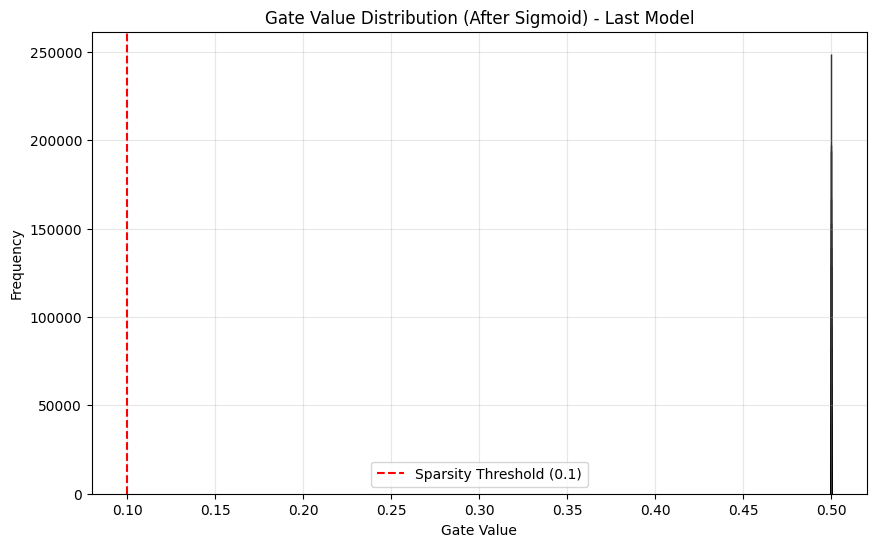

Sparsity for last model (gates < 0.1): 0.00%


In [24]:
# Print summary of all results
print("\n" + "="*50)
print("FINAL RESULTS SUMMARY")
print("="*50)
print("Lambda   | Accuracy | Sparsity")
print("---------|----------|---------")
for lam, acc, spar in results:
    print(f"{lam:8.0e} | {acc:8.2f}% | {spar:7.2f}%")
print("="*50)

# Visualize gate distribution for the last trained model
model.eval()
all_gates = []
# Collect gate values from all prunable layers
for layer in [model.fc1, model.fc2]:
    # Apply sigmoid to get gate values (0-1)
    g = torch.sigmoid(layer.gate_scores).detach().cpu().numpy().flatten()
    all_gates.extend(g)

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(all_gates, bins=50, edgecolor='black')
plt.title('Gate Value Distribution (After Sigmoid) - Last Model')
plt.xlabel('Gate Value')
plt.ylabel('Frequency')
# Add vertical line at sparsity threshold
plt.axvline(x=0.1, color='red', linestyle='--', label='Sparsity Threshold (0.1)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Calculate and display sparsity percentage for last model
sparsity = (np.array(all_gates) < 0.1).sum() / len(all_gates) * 100
print(f"Sparsity for last model (gates < 0.1): {sparsity:.2f}%")

## Analyzing Pruning Results

After training, we visualize the gate distribution to understand how well the pruning worked. The histogram shows the distribution of gate values (after sigmoid), and the red line indicates the sparsity threshold (0.1).

Gates below 0.1 are considered "pruned" (effectively zero). A good distribution should show:
- Many gates near 0 (pruned weights)
- Some gates near 1 (important weights)
- Few gates in the middle (uncertain weights)